## 1. Setup and Load Data
In this step, we import the Python libraries needed for data analysis and visualization (pandas, numpy, matplotlib, seaborn). We then load the cleaned and merged LendingClub dataset (which includes state GDP data) that was prepared in the data cleaning phase.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("LendingClub_GDP_Final.csv")
df.head()

,fico,dti,delinq_2yrs,inq_last_6mths,pub_rec,revol_util,total_acc,annual_inc,emp_length,home_ownership,loan_amnt,int_rate,term,grade,purpose,addr_state,state_gdp_2012,default
0,662.0,17.00,0.0,0.0,0.0,54.6%,15.0,53000.0,10+ years,MORTGAGE,2500.0,14.65%,36 months,C,home_improvement,GA,443566.1,0
1,732.0,8.21,0.0,0.0,0.0,26.1%,21.0,45600.0,10+ years,MORTGAGE,3000.0,7.90%,36 months,A,car,NV,127789.1,0
2,662.0,17.30,0.0,0.0,0.0,91.5%,13.0,76320.0,6 years,RENT,5600.0,19.22%,36 months,D,debt_consolidation,FL,768722.9,0
3,817.0,5.32,0.0,0.0,0.0,4.1%,6.0,65000.0,7 years,MORTGAGE,2800.0,7.62%,36 months,A,major_purchase,NY,1323400.8,0
4,702.0,4.23,0.0,2.0,0.0,21.3%,10.0,20700.0,< 1 year,OWN,1925.0,10.74%,36 months,B,home_improvement,AZ,268068.2,0


## 2. Check Available Columns
We list all column names in the dataset to confirm that the key variables needed for our analysis (fico, dti, annual_inc, int_rate, grade, state_gdp_2012, default) are all present.

In [2]:
df.columns.tolist()

['fico',
 'dti',
 'delinq_2yrs',
 'inq_last_6mths',
 'pub_rec',
 'revol_util',
 'total_acc',
 'annual_inc',
 'emp_length',
 'home_ownership',
 'loan_amnt',
 'int_rate',
 'term',
 'grade',
 'purpose',
 'addr_state',
 'state_gdp_2012',
 'default']

## 3. Overall Default Rate
Before examining individual risk factors, we first calculate the overall default rate in the dataset. Out of 10,447 loans, 1,779 (17.03%) were charged off, while 8,668 (82.97%) were fully paid. This indicates some class imbalance in the target variable, which will be considered when evaluating the predictive models.

In [3]:
# Check the distribution and overall rate of loan default
print(df['default'].value_counts())
print("\nDefault rate:", df['default'].mean())

default
0    8668
1    1779
Name: count, dtype: int64

Default rate: 0.17028812099167226


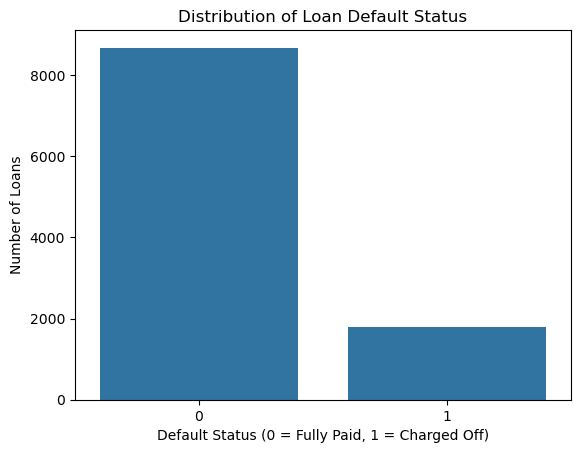

In [4]:
# Visualize the distribution of the target variable
sns.countplot(x='default', data=df)

plt.title('Distribution of Loan Default Status')
plt.xlabel('Default Status (0 = Fully Paid, 1 = Charged Off)')
plt.ylabel('Number of Loans')
plt.show()

## 4. FICO Score vs Default Status
We compare the distribution of FICO scores between borrowers who defaulted and those who did not, using a boxplot.

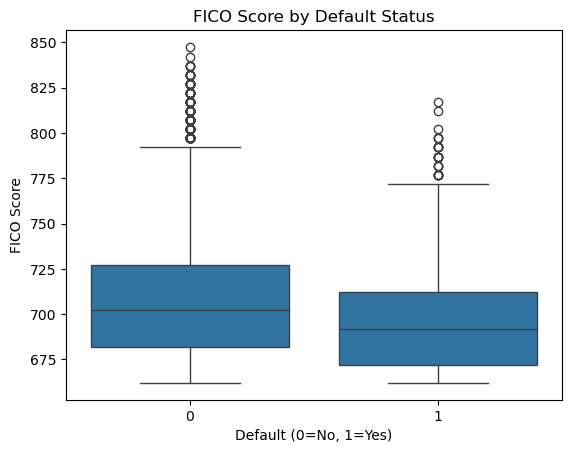

In [5]:
sns.boxplot(x='default', y='fico', data=df)
plt.title('FICO Score by Default Status')
plt.xlabel('Default (0=No, 1=Yes)')
plt.ylabel('FICO Score')
plt.show()

**Finding**: Defaulted loans tend to have lower FICO scores than fully paid loans, suggesting a negative association between FICO score and default risk. However, the distributions overlap substantially between the two groups.

## 5. DTI (Debt-to-Income Ratio) vs Default Status
We examine whether a borrower's debt-to-income ratio (DTI) is associated with default risk.

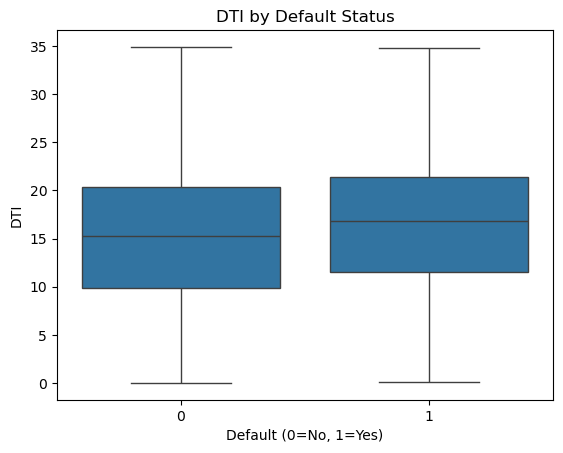

In [6]:
sns.boxplot(x='default', y='dti', data=df)
plt.title('DTI by Default Status')
plt.xlabel('Default (0=No, 1=Yes)')
plt.ylabel('DTI')
plt.show()

**Finding**: Defaulted borrowers tend to have somewhat higher DTI ratios than non-defaulted borrowers, suggesting that greater debt burden may be associated with higher default risk.

## 6. Annual Income vs Default Status
We examine whether a borrower's annual income is associated with default risk.

**Finding**: The median annual income for defaulted loans (approximately 55,000) is slightly lower than for non-defaulted loans (approximately 60,000), suggesting a modest negative relationship between income and default risk. However, the difference is less pronounced than DTI, and both groups show a wide, right-skewed income distribution.

**Note**: The y-axis was limited to \$200,000 to improve readability; a small number of high-income outliers exist beyond this range but are not excluded from the underlying data.

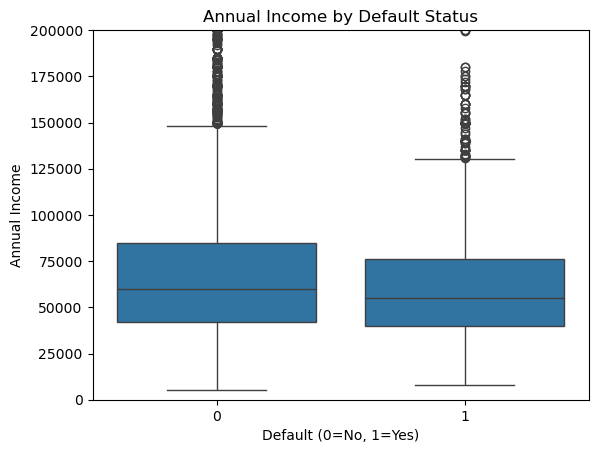

In [7]:
sns.boxplot(x='default', y='annual_inc', data=df)
plt.ylim(0, 200000)
plt.title('Annual Income by Default Status')
plt.xlabel('Default (0=No, 1=Yes)')
plt.ylabel('Annual Income')
plt.show()

**Data Check**: The distribution of annual income is right-skewed, with a median of 60,000 and mean of 69,143 (pulled upward by high earners, with a maximum of 1.23M). This confirms the data is valid and explains the wide spread and outliers observed in the boxplot above.

In [8]:
df['annual_inc'].describe()

count    1.044700e+04
mean     6.914995e+04
std      4.479704e+04
min      5.000000e+03
25%      4.200000e+04
50%      6.000000e+04
75%      8.400000e+04
max      1.233000e+06
Name: annual_inc, dtype: float64

## 7. Interest Rate vs Default Status
We examine whether the interest rate charged on a loan is associated with default risk. Since higher-risk borrowers are typically charged higher interest rates by LendingClub's pricing model, we expect a positive relationship between interest rate and default risk.

**Finding**: Borrowers who defaulted were charged a higher median interest rate (approximately 14.5%) compared to those who did not default (approximately 13%). This is the clearest relationship observed so far among the variables analyzed, likely because LendingClub's pricing model already assigns higher rates to riskier borrowers—meaning interest rate partially reflects the platform's own risk assessment.

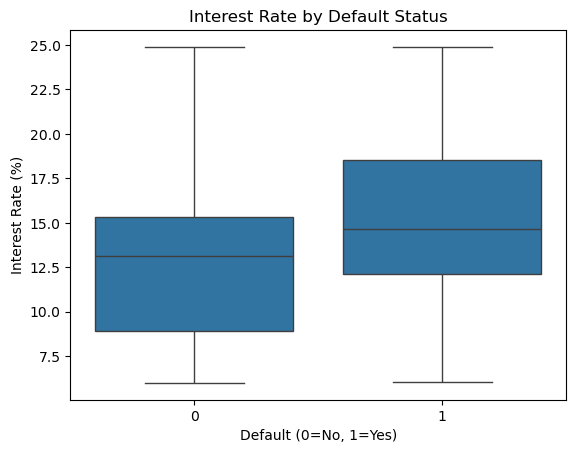

In [9]:
# Convert interest rate from percentage strings into numeric percentage values
df['int_rate_num'] = df['int_rate'].str.rstrip('%').astype(float)

sns.boxplot(x='default', y='int_rate_num', data=df)
plt.title('Interest Rate by Default Status')
plt.xlabel('Default (0=No, 1=Yes)')
plt.ylabel('Interest Rate (%)')
plt.show()

## 8. Loan Grade vs Default Rate
We examine how default rates vary across LendingClub's loan grade categories (A through G, where A represents the lowest risk and G the highest).

**Finding**: Default rate increases steadily and monotonically from Grade A (7%) to Grade G (50%), showing the clearest and strongest relationship observed among all variables analyzed. This confirms that LendingClub's internal grading system is a strong predictor of default risk, and is consistent with the higher interest rates observed for higher-risk grades in the previous section.

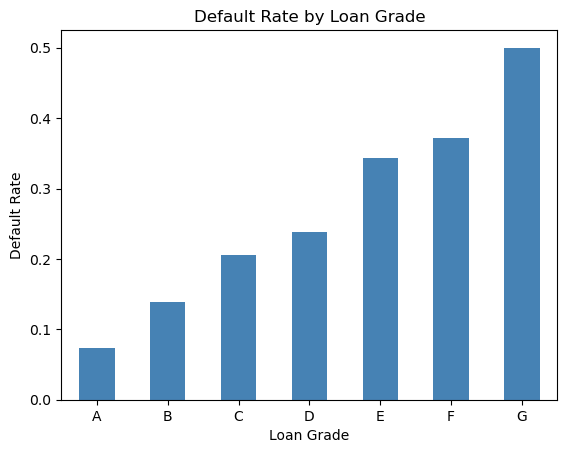

In [10]:
grade_default = df.groupby('grade')['default'].mean().sort_index()
grade_default.plot(kind='bar', color='steelblue')
plt.title('Default Rate by Loan Grade')
plt.xlabel('Loan Grade')
plt.ylabel('Default Rate')
plt.xticks(rotation=0)
plt.show()

## 9. Revolving Utilization vs Default Status

We examine whether borrowers with higher revolving credit utilization are more likely to default.

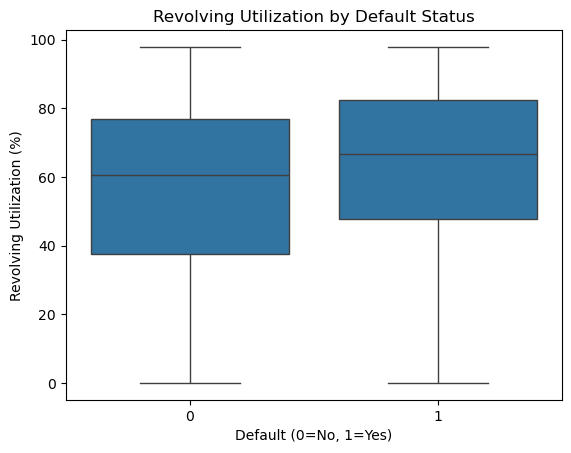

In [11]:
# Convert revolving utilization from percentage strings into numeric percentage values
df['revol_util_num'] = (
    df['revol_util']
    .str.rstrip('%')
    .astype(float)
)

# Compare revolving utilization between defaulted and fully paid loans
sns.boxplot(
    x='default',
    y='revol_util_num',
    data=df
)

plt.title('Revolving Utilization by Default Status')
plt.xlabel('Default (0=No, 1=Yes)')
plt.ylabel('Revolving Utilization (%)')
plt.show()

In [12]:
# Compare revolving utilization statistics by default status
df.groupby('default')['revol_util_num'].describe()

,count,mean,std,min,25%,50%,75%,max
default,,,,,,,,
0,8661.0,56.161436,25.797955,0.0,37.7,60.7,77.0,97.9
1,1777.0,62.664547,24.067505,0.0,47.8,66.6,82.3,97.9


**Finding**: Defaulted borrowers tend to have higher revolving utilization than fully paid borrowers. The median revolving utilization is approximately 66.6% for defaulted loans compared with 60.7% for fully paid loans, suggesting that higher credit utilization may be associated with greater default risk.

## 10. State GDP vs Default Status
We examine whether the overall economic output of a borrower's state, measured by 2012 total state GDP, is associated with default risk.

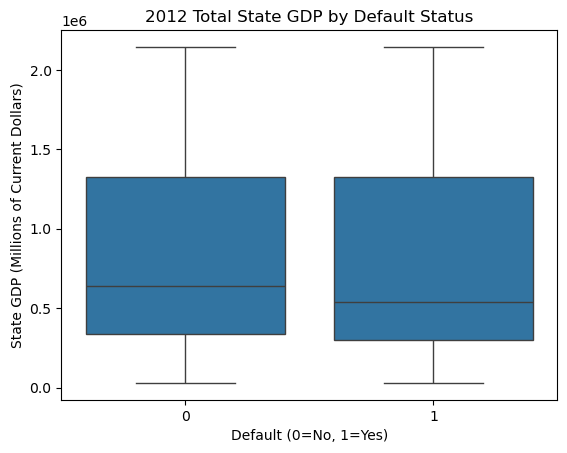

In [13]:
# Compare 2012 total state GDP between defaulted and fully paid loans
sns.boxplot(
    x='default',
    y='state_gdp_2012',
    data=df
)

plt.title('2012 Total State GDP by Default Status')
plt.xlabel('Default (0=No, 1=Yes)')
plt.ylabel('State GDP (Millions of Current Dollars)')
plt.show()

In [14]:
# Compare state GDP statistics by default status
df.groupby('default')['state_gdp_2012'].describe()

,count,mean,std,min,25%,50%,75%,max
default,,,,,,,,
0,8668.0,888736.956080,702456.549194,28893.6,334555.5,640663.1,1323400.8,2144089.6
1,1779.0,854790.738505,692361.118137,28893.6,296272.5,540882.4,1323400.8,2144089.6


**Finding**: Defaulted borrowers tend to be located in states with somewhat lower total GDP. The median state GDP is approximately 540,882 million dollars for defaulted loans compared with 640,663 million dollars for fully paid loans. However, the distributions overlap substantially, suggesting that the direct association between total state GDP and default risk may be relatively weak.

## 11. Correlation Analysis
We examine the correlations among key numerical borrower, loan, and economic variables and their relationships with loan default.

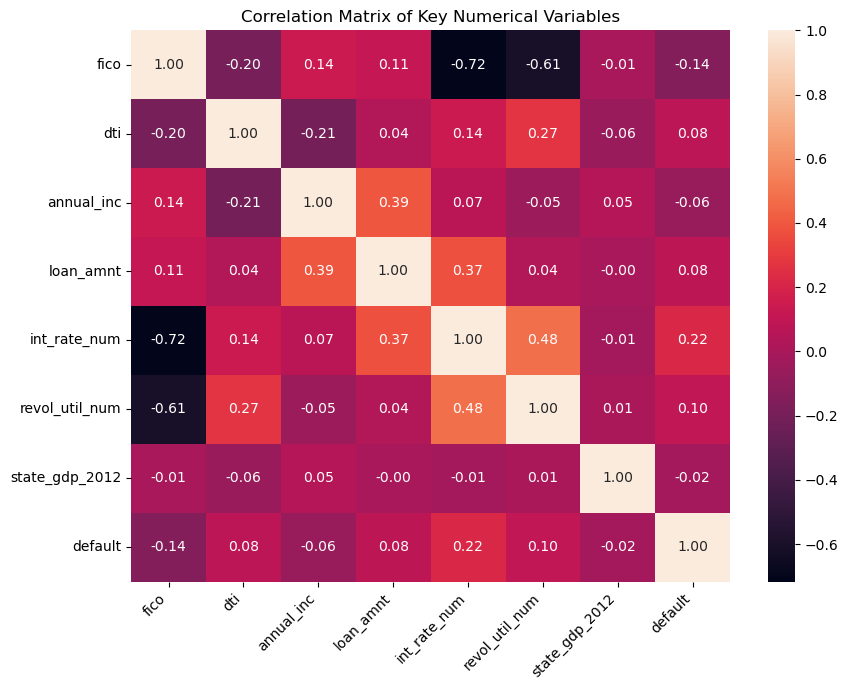

In [15]:
# Select key numerical variables for correlation analysis
correlation_variables = [
    'fico',
    'dti',
    'annual_inc',
    'loan_amnt',
    'int_rate_num',
    'revol_util_num',
    'state_gdp_2012',
    'default'
]

# Calculate the correlation matrix
correlation_matrix = df[correlation_variables].corr()

# Visualize correlations between key numerical variables
plt.figure(figsize=(9, 7))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt='.2f'
)

plt.title('Correlation Matrix of Key Numerical Variables')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

**Finding**: Among the numerical variables examined, interest rate has the strongest positive correlation with default (0.22), while FICO score has the strongest negative correlation (−0.14). Revolving utilization, DTI, loan amount, and annual income show relatively weak correlations with default. State GDP has a correlation of approximately −0.02 with default, indicating very little direct linear association between total state GDP and individual loan default in this sample.

## 12. Loan Amount vs Default Status

We examine whether loan amounts differ between fully paid and defaulted loans.

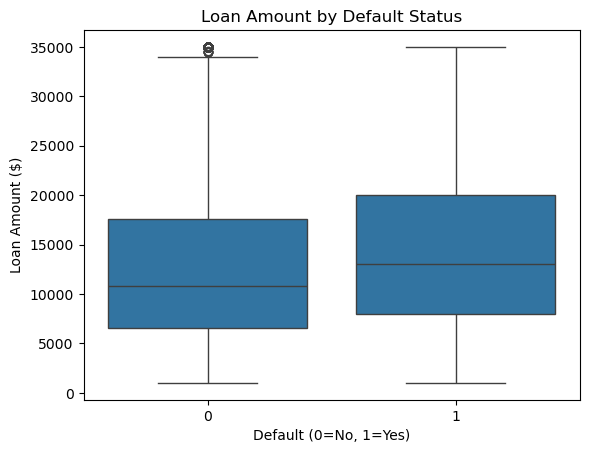

In [16]:
# Compare loan amount between defaulted and fully paid loans
sns.boxplot(
    x='default',
    y='loan_amnt',
    data=df
)

plt.title('Loan Amount by Default Status')
plt.xlabel('Default (0=No, 1=Yes)')
plt.ylabel('Loan Amount ($)')
plt.show()

In [17]:
# Compare loan amount statistics by default status
df.groupby('default')['loan_amnt'].describe()

,count,mean,std,min,25%,50%,75%,max
default,,,,,,,,
0,8668.0,12840.127480,8072.294240,1000.0,6600.0,10800.0,17600.0,35000.0
1,1779.0,14653.175942,8651.894768,1000.0,8000.0,13000.0,20000.0,35000.0


**Finding**: Defaulted loans tend to have higher loan amounts than fully paid loans. The median loan amount is approximately $13,000$ for defaulted loans compared with $10,800$ for fully paid loans. However, the distributions overlap substantially, suggesting that loan amount alone has a relatively weak association with default risk.

## 13. Loan Term vs Default Rate
We examine whether default rates differ across loan terms.

In [18]:
# Calculate the number of loans and default rate for each loan term
term_summary = (
    df.groupby('term')['default']
    .agg(['count', 'mean'])
)

# Rename the columns for easier interpretation
term_summary.columns = [
    'Number of Loans',
    'Default Rate'
]

term_summary

,Number of Loans,Default Rate
term,,
36 months,8469,0.142284
60 months,1978,0.290192


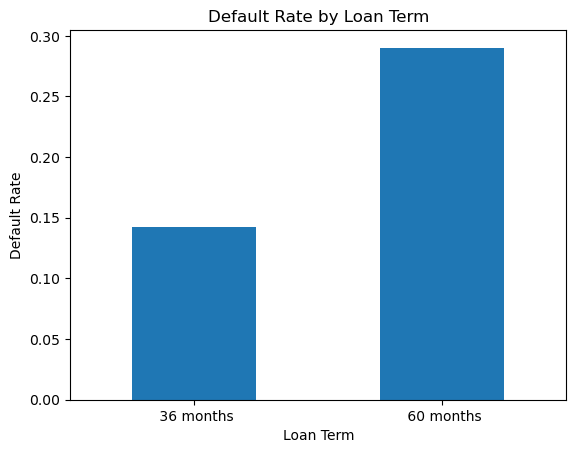

In [19]:
# Visualize the default rate across different loan terms
term_default = (
    df.groupby('term')['default']
    .mean()
)

term_default.plot(kind='bar')

plt.title('Default Rate by Loan Term')
plt.xlabel('Loan Term')
plt.ylabel('Default Rate')
plt.xticks(rotation=0)
plt.show()

**Finding**: Longer-term loans have a substantially higher default rate. The default rate is approximately 29.02% for 60-month loans compared with 14.23% for 36-month loans, suggesting that longer loan terms are associated with greater default risk.

## 14. Loan Purpose vs Default Rate
We examine whether default rates differ across different loan purposes.

In [20]:
# Calculate the number of loans and default rate for each loan purpose
purpose_summary = (
    df.groupby('purpose')['default']
    .agg(['count', 'mean'])
    .sort_values('mean', ascending=False)
)

# Rename the columns for easier interpretation
purpose_summary.columns = [
    'Number of Loans',
    'Default Rate'
]

purpose_summary

,Number of Loans,Default Rate
purpose,,
vacation,88,0.261364
small_business,325,0.233846
house,108,0.203704
other,702,0.189459
debt_consolidation,5573,0.184640
medical,143,0.181818
credit_card,1877,0.143847
moving,113,0.141593
renewable_energy,15,0.133333


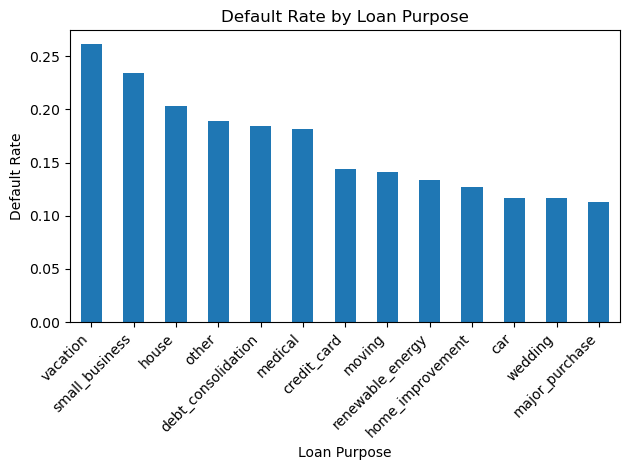

In [21]:
# Visualize the default rate across different loan purposes
purpose_default = (
    df.groupby('purpose')['default']
    .mean()
    .sort_values(ascending=False)
)

purpose_default.plot(kind='bar')

plt.title('Default Rate by Loan Purpose')
plt.xlabel('Loan Purpose')
plt.ylabel('Default Rate')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

**Finding**: Default rates vary across loan purposes. Vacation and small-business loans show relatively high default rates of approximately 26.14% and 23.38%, respectively, while major-purchase loans have the lowest default rate at approximately 11.27%. However, some categories contain relatively few loans, so their default rates should be interpreted cautiously.

## 15. EDA Summary

The exploratory analysis identifies several patterns associated with loan default. Defaulted loans tend to have lower FICO scores, higher debt-to-income ratios, higher interest rates, higher revolving utilization, and larger loan amounts. Default rates also vary across loan grades, loan terms, and loan purposes. In particular, 60-month loans have a substantially higher default rate than 36-month loans.

For the state-level economic variable, defaulted borrowers tend to be located in states with somewhat lower total GDP. However, the GDP distributions for defaulted and fully paid loans overlap substantially, and the correlation between state GDP and default is approximately -0.02, indicating a weak direct linear association.

Overall, the EDA suggests that traditional borrower and loan characteristics are associated with default risk, while the direct relationship between total state GDP and default appears relatively weak. However, EDA alone cannot determine whether state GDP provides additional predictive value after controlling for traditional credit characteristics. This will be examined in the subsequent statistical analysis and machine learning stages by comparing baseline models with models that incorporate state GDP.